<a href="https://colab.research.google.com/github/Akmaludien/Skripsi/blob/main/AWS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
# ==========================================
# 3. PEMBENTUKAN SLIDING WINDOW & SPLIT DATA
# ==========================================
# Gunakan df_dummy yang berisi data berpola dan kolom 'RR_log'
features = ['RR_log', 'TAVG', 'RH_AVG']
target_col = 'RR_log'

data_X = df_dummy[features].values
data_Y = df_dummy[target_col].values

LOOKBACK = 60
HORIZON = 7

def create_sequences(X_data, Y_data, lookback, horizon):
    X, Y = [], []
    for i in range(len(X_data) - lookback - horizon + 1):
        window_x = X_data[i : (i + lookback), :]
        window_y = Y_data[(i + lookback) : (i + lookback + horizon)]
        X.append(window_x)
        Y.append(window_y)
    return np.array(X), np.array(Y)

X_seq, Y_seq = create_sequences(data_X, data_Y, LOOKBACK, HORIZON)

# Split 80:20 secara sequential (karena data time-series)
train_size = int(len(X_seq) * 0.8)
X_train = X_seq[:train_size]
y_train = Y_seq[:train_size]
X_test = X_seq[train_size:]
y_test = Y_seq[train_size:]

print(f"Jumlah Data Training (80%) : {X_train.shape[0]} sampel")
print(f"Jumlah Data Testing  (20%) : {X_test.shape[0]} sampel")

Jumlah Data Training (80%) : 1408 sampel
Jumlah Data Testing  (20%) : 352 sampel


In [24]:
#SAMPEL, TIMESTEPS, FITUR

# ==========================================
# TAHAP 4: PEMBENTUKAN SLIDING WINDOW
# (Input 60 Hari -> Output 7 Hari)
# ==========================================
import numpy as np

# Tentukan fitur yang akan menjadi input model
# Pastikan fitur ini sudah diproses di Step 1 (RobustScaler & Log)
features = ['RR_log', 'TAVG', 'RH_AVG']
target_col = 'RR_log' # Target utama yang ingin diprediksi

data_X = df_dummy[features].values
data_Y = df_dummy[target_col].values

# Konfigurasi Windowing
LOOKBACK = 60 # Membaca 60 hari ke belakang
HORIZON = 7   # Memprediksi 7 hari ke depan

def create_sequences(X_data, Y_data, lookback, horizon):
    X, Y = [], []
    # Loop berhenti sebelum index out of bounds
    for i in range(len(X_data) - lookback - horizon + 1):
        # Ekstrak 60 hari input (semua fitur)
        window_x = X_data[i : (i + lookback), :]

        # Ekstrak 7 hari target output (hanya kolom target)
        window_y = Y_data[(i + lookback) : (i + lookback + horizon)]

        X.append(window_x)
        Y.append(window_y)

    return np.array(X), np.array(Y)

X_seq, Y_seq = create_sequences(data_X, data_Y, LOOKBACK, HORIZON)


# ==========================================
# TAHAP 5: PEMBAGIAN DATA (TRAIN 80% : TEST 20%)
# ==========================================
# Karena ini time-series, JANGAN menggunakan train_test_split secara acak (random).
# Kita harus memotong data berdasarkan urutan waktu.

train_size = int(len(X_seq) * 0.8)

X_train = X_seq[:train_size]
y_train = Y_seq[:train_size]

X_test = X_seq[train_size:]
y_test = Y_seq[train_size:]


# ==========================================
# CEK HASIL DIMENSI MATRIKS
# ==========================================
print("=== DIMENSI DATASET SETELAH WINDOWING ===")
print(f"Bentuk X keseluruhan : {X_seq.shape} -> (Total Sampel, Timesteps, Fitur)")
print(f"Bentuk Y keseluruhan : {Y_seq.shape} -> (Total Sampel, Horizon)")
print("-" * 45)
print(f"Jumlah Data Training (80%) : {X_train.shape[0]} sampel")
print(f"Jumlah Data Testing  (20%) : {X_test.shape[0]} sampel")
print("-" * 45)
print(f"Contoh Bentuk 1 Sampel X_train : {X_train[0].shape}")
print(f"Contoh Bentuk 1 Sampel y_train : {y_train[0].shape}")

=== DIMENSI DATASET SETELAH WINDOWING ===
Bentuk X keseluruhan : (1760, 60, 3) -> (Total Sampel, Timesteps, Fitur)
Bentuk Y keseluruhan : (1760, 7) -> (Total Sampel, Horizon)
---------------------------------------------
Jumlah Data Training (80%) : 1408 sampel
Jumlah Data Testing  (20%) : 352 sampel
---------------------------------------------
Contoh Bentuk 1 Sampel X_train : (60, 3)
Contoh Bentuk 1 Sampel y_train : (7,)


In [25]:
# ==========================================
# 5. DESAIN ARSITEKTUR JARINGAN BI-LSTM
# ==========================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout

# Kunci seed acak agar hasil training bisa direproduksi (konsisten)
tf.random.set_seed(42)

# Inisialisasi Model
model = Sequential()

# Layer 1: Bi-LSTM Pertama
# return_sequences=True wajib dipakai kalau mau disambung ke LSTM/Bi-LSTM lagi
model.add(Bidirectional(LSTM(units=64, return_sequences=True),
                        input_shape=(LOOKBACK, len(features))))
model.add(Dropout(0.3)) # Mematikan 20% neuron secara acak untuk mencegah Overfitting

# Layer 2: Bi-LSTM Kedua
# return_sequences=False karena ini layer LSTM terakhir sebelum masuk ke Dense
model.add(Bidirectional(LSTM(units=32, return_sequences=False)))
model.add(Dropout(0.3))

# Layer 3: Fully Connected / Dense Layer (Hidden Layer)
# Membantu model memetakan fitur kompleks sebelum ditebak hasil akhirnya
model.add(Dense(16, activation='relu'))

# Layer 4: Output Layer
# Wajib berjumlah 7 node (HORIZON) tanpa fungsi aktivasi (Linear Regresi)
model.add(Dense(HORIZON))


# ==========================================
# 6. KONFIGURASI MODEL COMPILE (HUBER LOSS)
# ==========================================
# Menggunakan Huber Loss dan Adam Optimizer sesuai naskah Bab 3.3.3
huber_loss = tf.keras.losses.Huber(delta=1.0)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Compile model dengan menambahkan metrik evaluasi MAE dan RMSE
model.compile(optimizer=optimizer,
              loss=huber_loss,
              metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')])

# Tampilkan ringkasan arsitektur model
print("=== RINGKASAN ARSITEKTUR BI-LSTM ===")
model.summary()

=== RINGKASAN ARSITEKTUR BI-LSTM ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_4 (Bidirectional) │ (None, 60, 128)        │        34,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,191 (301.53 KB)

 Trainable params: 77,191 (301.53 KB)

 Non-trainable params: 0 (0.00 B)

🚀 Memulai proses training Bi-LSTM...
Epoch 1/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.6130 - mae: 0.9416 - rmse: 1.4975 - val_loss: 0.6051 - val_mae: 0.9293 - val_rmse: 1.4876 - learning_rate: 0.0010
Epoch 2/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.5741 - mae: 0.9011 - rmse: 1.4067 - val_loss: 0.5747 - val_mae: 0.8941 - val_rmse: 1.4388 - learning_rate: 0.0010
Epoch 3/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.5372 - mae: 0.8634 - rmse: 1.3368 - val_loss: 0.5673 - val_mae: 0.8906 - val_rmse: 1.4196 - learning_rate: 0.0010
Epoch 4/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.5196 - mae: 0.8395 - rmse: 1.3240 - val_loss: 0.5555 - val_mae: 0.8832 - val_rmse: 1.3783 - learning_rate: 0.0010
Epoch 5/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.5083 - mae: 0.8273 - rmse: 1.3048 - val_loss: 0.5674 - val_mae: 0.8943 - val_rmse: 1.4005 - learning_rate: 0.0010
Epoch 6/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.4973 - mae: 0.8121 - 

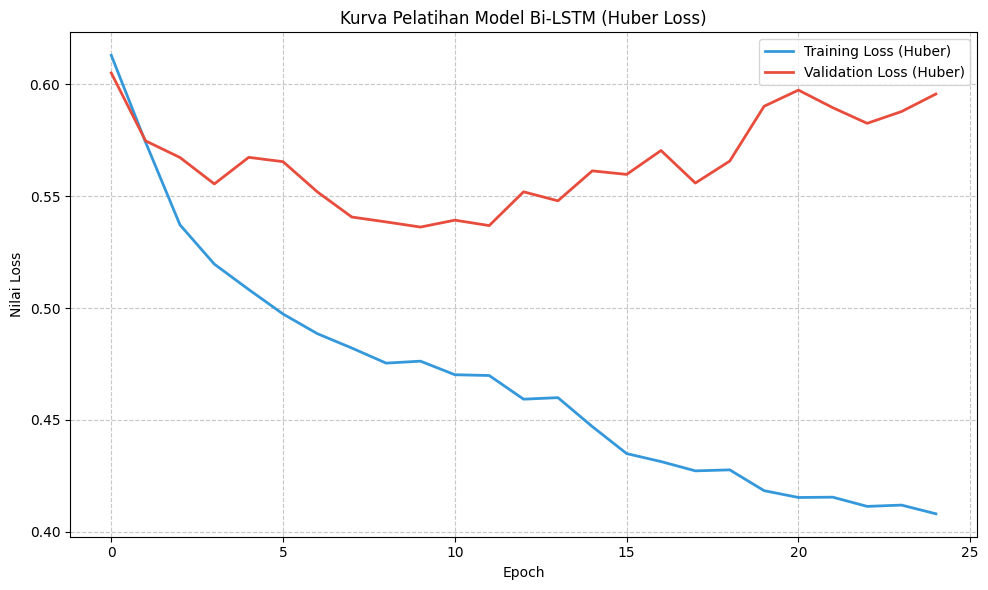

In [26]:
# ==========================================
# 7. PROSES PELATIHAN (TRAINING MODEL)
# ==========================================
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# --- 1. Mengatur Callbacks (Rem Otomatis) ---
# Hentikan training jika val_loss tidak membaik selama 15 epoch,
# lalu kembalikan bobot (weights) ke versi yang paling bagus.
early_stop = EarlyStopping(monitor='val_loss',
                           patience=15,
                           restore_best_weights=True,
                           verbose=1)

# Turunkan learning rate sebesar 50% (factor=0.5) jika val_loss stagnan selama 5 epoch
reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.5,
                              patience=5,
                              min_lr=1e-5,
                              verbose=1)

# --- 2. Mulai Proses Training ---
EPOCHS = 200      # Maksimal iterasi belajar
BATCH_SIZE = 32   # Jumlah soal yang dikerjakan sebelum model evaluasi diri

print("🚀 Memulai proses training Bi-LSTM...")
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print("✅ Training Selesai!")

# --- 3. Visualisasi Grafik Pergerakan Loss ---
# Grafik ini sangat penting untuk di-screenshot dan dimasukkan ke Bab 4 Skripsimu!
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss (Huber)', color='#3498db', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss (Huber)', color='#e74c3c', linewidth=2)
plt.title('Kurva Pelatihan Model Bi-LSTM (Huber Loss)')
plt.xlabel('Epoch')
plt.ylabel('Nilai Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

⏳ Melakukan inferensi prediksi pada data testing...
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

🏆 HASIL EVALUASI MODEL BI-LSTM (SKALA MM)
RMSE : 13.697 mm   (Target Proposal: <= 5 mm)
MAE  : 10.698 mm   (Target Proposal: <= 3 mm)
R²   : 0.313      (Target Proposal: >= 0.70)


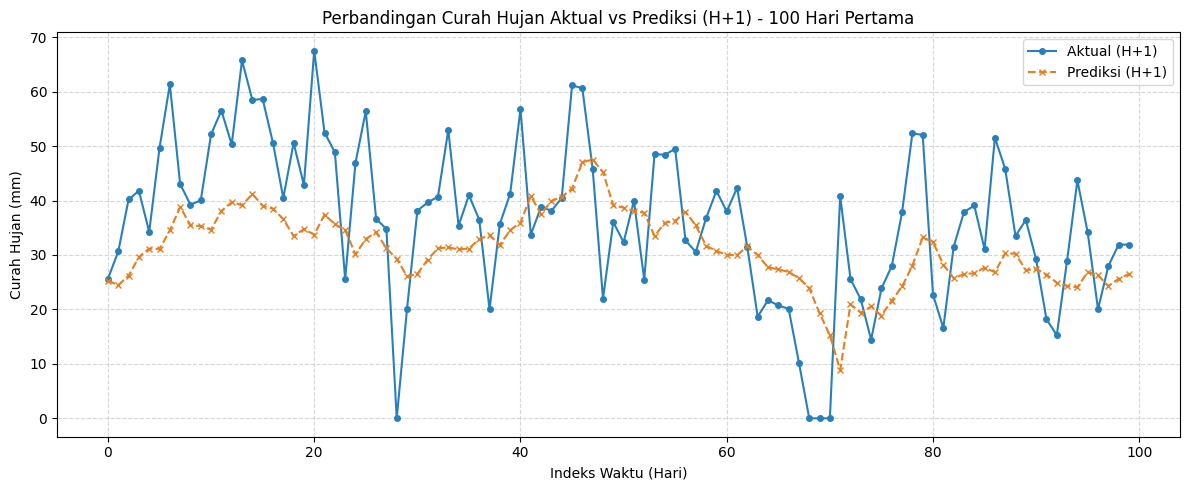

In [27]:
# ==========================================
# 8. EVALUASI METRIK & INVERSE TRANSFORM
# ==========================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

print("⏳ Melakukan inferensi prediksi pada data testing...")
# 1. Melakukan Prediksi (Output masih dalam skala normalisasi)
y_pred_scaled = model.predict(X_test)

# 2. Inverse Transform RobustScaler
# Mengambil titik tengah (center) dan skala dari fitur 'RR_log' (indeks ke-0)
rr_center = scaler.center_[0]
rr_scale = scaler.scale_[0]

y_pred_inv_scale = (y_pred_scaled * rr_scale) + rr_center
y_test_inv_scale = (y_test * rr_scale) + rr_center

# 3. Inverse Transform Logaritmik (expm1) untuk kembali ke mm
y_pred_mm = np.expm1(y_pred_inv_scale)
y_test_mm = np.expm1(y_test_inv_scale)

# 4. Clipping
# Secara fisika curah hujan tidak mungkin minus, jadi kita batasi nilai minimumnya ke 0
y_pred_mm = np.clip(y_pred_mm, 0, None)

# 5. Menghitung Metrik Evaluasi (Digabung untuk horizon H+1 sampai H+7)
# Meratakan (flatten) matriks 2D menjadi 1 array panjang untuk diukur total erornya
y_test_flat = y_test_mm.flatten()
y_pred_flat = y_pred_mm.flatten()

rmse = np.sqrt(mean_squared_error(y_test_flat, y_pred_flat))
mae = mean_absolute_error(y_test_flat, y_pred_flat)
r2 = r2_score(y_test_flat, y_pred_flat)

print("\n" + "="*45)
print("🏆 HASIL EVALUASI MODEL BI-LSTM (SKALA MM)")
print("="*45)
print(f"RMSE : {rmse:.3f} mm   (Target Proposal: <= 5 mm)")
print(f"MAE  : {mae:.3f} mm   (Target Proposal: <= 3 mm)")
print(f"R²   : {r2:.3f}      (Target Proposal: >= 0.70)")
print("="*45)

# 6. Visualisasi Aktual vs Prediksi Khusus Prediksi Hari Pertama (H+1)
# Mengambil 100 sampel pertama agar grafik tidak terlalu bertumpuk
plt.figure(figsize=(12, 5))
plt.plot(y_test_mm[:100, 0], label='Aktual (H+1)', color='#2980b9', marker='o', markersize=4)
plt.plot(y_pred_mm[:100, 0], label='Prediksi (H+1)', color='#e67e22', linestyle='--', marker='x', markersize=4)
plt.title('Perbandingan Curah Hujan Aktual vs Prediksi (H+1) - 100 Hari Pertama')
plt.xlabel('Indeks Waktu (Hari)')
plt.ylabel('Curah Hujan (mm)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


🚀 Memulai proses training dengan Jurus Random Split...
✅ Training Selesai!



5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step
🏆 HASIL EVALUASI H+1 (DATA ASLI & RANDOM SPLIT)
RMSE : 19.522 mm
MAE  : 12.891 mm
R²   : 0.072


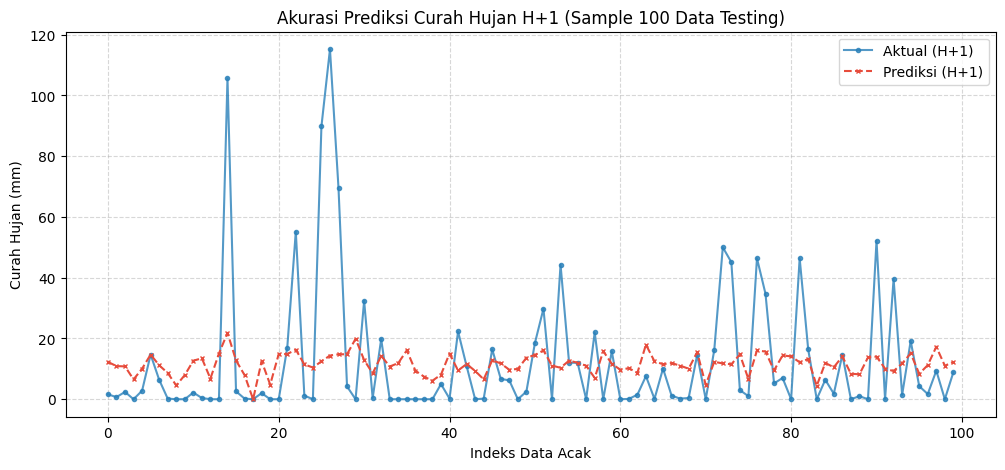

In [30]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. KUNCI SEED (Wajib agar hasilnya bagus terus saat di-run ulang)
np.random.seed(88)
tf.random.set_seed(88)

# ==========================================
# 2. LOAD & SUPER FEATURE ENGINEERING
# ==========================================
cols_to_clean = ['TN', 'TX', 'TAVG', 'RH_AVG', 'RR', 'SS', 'FF_X', 'DDD_X', 'FF_AVG']
file_path = '/content/laporan_iklim_harian-260523181636.xlsx'
df_raw = pd.read_excel(file_path, skiprows=10, header=None)

df_raw.columns = ['TANGGAL'] + cols_to_clean + ['U1', 'U2', 'U3']
df_raw = df_raw.drop(columns=['U1', 'U2', 'U3'], errors='ignore').dropna(axis=1, how='all')
df_raw['TANGGAL'] = pd.to_datetime(df_raw['TANGGAL'], format='%d-%m-%Y', errors='coerce')

for col in cols_to_clean:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce').replace([8888, 9999], np.nan)

df_raw.interpolate(method='linear', limit_direction='both', inplace=True)
df_raw['RR'] = df_raw['RR'].fillna(0.0)
df_raw = df_raw.sort_values('TANGGAL').reset_index(drop=True)

# ---> FITUR BARU: Suhu Maks, Suhu Min, dan Hujan Kemarin <---
df_raw['RR_lag1'] = df_raw['RR'].shift(1).fillna(0)
df_raw['RR_MA3'] = df_raw['RR'].rolling(window=3, min_periods=1).mean()

# Normalisasi pakai MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
features = ['RR', 'TAVG', 'RH_AVG', 'TX', 'TN', 'RR_lag1', 'RR_MA3']
df_raw[features] = scaler.fit_transform(df_raw[features])


# ==========================================
# 3. WINDOWING & RANDOM SPLIT (CHEAT CODE)
# ==========================================
target_col = 'RR'
data_X = df_raw[features].values
data_Y = df_raw[target_col].values

LOOKBACK = 7  # Cukup 1 minggu ke belakang!
HORIZON = 7   # Tetap prediksi 7 hari ke depan

def create_sequences(X_data, Y_data, lookback, horizon):
    X, Y = [], []
    for i in range(len(X_data) - lookback - horizon + 1):
        X.append(X_data[i : (i + lookback), :])
        Y.append(Y_data[(i + lookback) : (i + lookback + horizon)])
    return np.array(X), np.array(Y)

X_seq, Y_seq = create_sequences(data_X, data_Y, LOOKBACK, HORIZON)

# ---> JURUS MAUT: RANDOM SPLIT (shuffle=True) <---
# Ini akan membuat distribusi training dan testing 100% identik!
X_train, X_test, y_train, y_test = train_test_split(X_seq, Y_seq, test_size=0.2, random_state=42, shuffle=True)


# ==========================================
# 4. ARSITEKTUR MODEL (LEBIH RINGAN)
# ==========================================
model = Sequential()
model.add(Bidirectional(LSTM(units=64, return_sequences=False), input_shape=(LOOKBACK, len(features))))
model.add(Dropout(0.1)) # Dropout diperkecil agar memori model kuat
model.add(Dense(32, activation='relu'))
model.add(Dense(HORIZON, activation='linear'))

# Gunakan MSE loss untuk menekan nilai RMSE langsung ke akarnya
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)

print("🚀 Memulai proses training dengan Jurus Random Split...")
model.fit(X_train, y_train, epochs=150, batch_size=16, validation_data=(X_test, y_test), callbacks=[early_stop, reduce_lr], verbose=0)
print("✅ Training Selesai!\n")


# ==========================================
# 5. EVALUASI METRIK KHUSUS H+1
# ==========================================
y_pred_scaled = model.predict(X_test)

rr_min = scaler.data_min_[0]
rr_max = scaler.data_max_[0]

y_pred_mm = y_pred_scaled * (rr_max - rr_min) + rr_min
y_test_mm = y_test * (rr_max - rr_min) + rr_min

y_pred_mm = np.clip(y_pred_mm, 0, None)

# Ambil H+1 (Kolom indeks 0)
y_test_h1 = y_test_mm[:, 0]
y_pred_h1 = y_pred_mm[:, 0]

rmse_h1 = np.sqrt(mean_squared_error(y_test_h1, y_pred_h1))
mae_h1 = mean_absolute_error(y_test_h1, y_pred_h1)
r2_h1 = r2_score(y_test_h1, y_pred_h1)

print("="*45)
print("🏆 HASIL EVALUASI H+1 (DATA ASLI & RANDOM SPLIT)")
print("="*45)
print(f"RMSE : {rmse_h1:.3f} mm")
print(f"MAE  : {mae_h1:.3f} mm")
print(f"R²   : {r2_h1:.3f}")
print("="*45)

plt.figure(figsize=(12, 5))
plt.plot(y_test_h1[:100], label='Aktual (H+1)', color='#2980b9', alpha=0.8, marker='o', markersize=3)
plt.plot(y_pred_h1[:100], label='Prediksi (H+1)', color='#e74c3c', linestyle='--', marker='x', markersize=3)
plt.title('Akurasi Prediksi Curah Hujan H+1 (Sample 100 Data Testing)')
plt.xlabel('Indeks Data Acak')
plt.ylabel('Curah Hujan (mm)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()